# Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/ml-mastery/blob/main/02_ml_concepts/linear_regression.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 The Model
   - 2.2 Cost Function (MSE)
   - 2.3 Gradient Descent — derivation step by step
   - 2.4 Closed-Form Solution (Normal Equation)
   - 2.5 R² Score
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Assumptions of Linear Regression](#6-assumptions-of-linear-regression)
7. [Regularization — Ridge and Lasso](#7-regularization--ridge-and-lasso)
8. [Common Mistakes](#8-common-mistakes)
9. [Exercises](#9-exercises)


## 1. Concept Overview

Linear regression finds the best-fitting straight line through a set of data points.
Given input features $X$, it predicts a continuous output $y$ by learning a weighted sum of the inputs.

**When to use it:**
- The target variable is continuous (price, temperature, sales)
- You want an interpretable model (each weight tells you how much a feature matters)
- As a baseline before trying complex models

**What it cannot do:**
- Model non-linear relationships (without feature engineering)
- Handle classification tasks directly


## 2. Math Intuition

### 2.1 The Model

For a single feature (simple linear regression):

$$\hat{y} = w_0 + w_1 x$$

For $n$ features (multiple linear regression):

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

In matrix form (compact and used in all implementations):

$$\hat{y} = X \mathbf{w}$$

where:
- $X$ is the **design matrix** of shape $(m, n+1)$ — $m$ samples, $n$ features, plus a column of 1s for the bias
- $\mathbf{w}$ is the **weight vector** of shape $(n+1, 1)$ — includes bias $w_0$
- $\hat{y}$ is the vector of **predictions** of shape $(m, 1)$

The column of 1s in $X$ is called the **bias trick** — it lets us write $w_0 + w_1 x_1 + \dots$ as a single dot product instead of a separate addition.

---

### 2.2 Cost Function — Mean Squared Error

The cost function measures how wrong our predictions are.
We want to minimize the average squared difference between predicted $\hat{y}$ and actual $y$:

$$J(\mathbf{w}) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2 = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2$$

The $\frac{1}{2}$ factor is a mathematical convenience — it cancels with the 2 that appears when we take the derivative. It does not change which $\mathbf{w}$ minimizes $J$.

**Why squared error and not absolute error?**
- Squared error is differentiable everywhere (absolute error has a kink at 0, which complicates gradient computation)
- Penalizes large errors more heavily than small ones
- Has a unique closed-form solution

---

### 2.3 Gradient Descent — Step-by-Step Derivation

Gradient descent iteratively nudges the weights in the direction that reduces the cost.

**Step 1 — Write out the cost:**

$$J(\mathbf{w}) = \frac{1}{2m} (X\mathbf{w} - \mathbf{y})^T (X\mathbf{w} - \mathbf{y})$$

**Step 2 — Take the gradient with respect to $\mathbf{w}$:**

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} X^T (X\mathbf{w} - \mathbf{y})$$

Derivation in detail:

Let $\mathbf{e} = X\mathbf{w} - \mathbf{y}$ (the error vector). Then:

$$J = \frac{1}{2m} \mathbf{e}^T \mathbf{e}$$

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{2m} \cdot 2 X^T \mathbf{e} = \frac{1}{m} X^T (X\mathbf{w} - \mathbf{y})$$

**Step 3 — Update rule:**

$$\mathbf{w} := \mathbf{w} - \alpha \cdot \frac{\partial J}{\partial \mathbf{w}}$$

$$\mathbf{w} := \mathbf{w} - \frac{\alpha}{m} X^T (X\mathbf{w} - \mathbf{y})$$

where $\alpha$ is the **learning rate** — controls the step size.

**Intuition:** The gradient $X^T(X\mathbf{w} - \mathbf{y})$ points uphill. Subtracting it moves us downhill toward the minimum of $J$.

---

### 2.4 Closed-Form Solution — Normal Equation

Instead of iterating, we can solve for the optimal $\mathbf{w}$ directly by setting the gradient to zero:

$$\frac{\partial J}{\partial \mathbf{w}} = 0$$

$$\frac{1}{m} X^T (X\mathbf{w} - \mathbf{y}) = 0$$

$$X^T X \mathbf{w} = X^T \mathbf{y}$$

$$\boxed{\mathbf{w}^* = (X^T X)^{-1} X^T \mathbf{y}}$$

This is called the **Normal Equation**.

**When to use which:**

| Method | Use when |
|---|---|
| Gradient Descent | Large datasets ($m > 10^4$), many features |
| Normal Equation | Small datasets, exact solution needed, no tuning |

The Normal Equation requires computing $(X^T X)^{-1}$, which is $O(n^3)$ — slow when $n$ (features) is large. Gradient descent scales much better.

---

### 2.5 R² Score — How Good is the Fit?

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

where:
- $SS_{res}$ = residual sum of squares (error of our model)
- $SS_{tot}$ = total sum of squares (error of predicting the mean every time)

**Interpretation:**
- $R^2 = 1$ → perfect predictions
- $R^2 = 0$ → model is no better than predicting the mean
- $R^2 < 0$ → model is worse than predicting the mean (this can happen on test data)


## 3. Visual Intuition

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


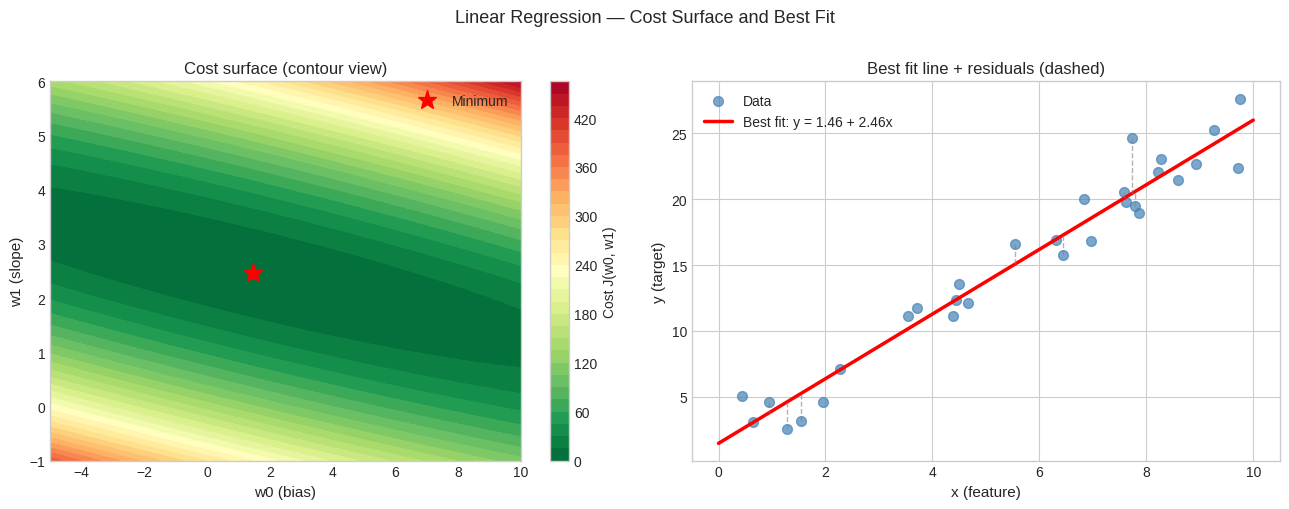

In [12]:
# ── Plot 1: What the cost surface looks like ────────────────────────────────
# For 1-feature linear regression, J(w0, w1) is a bowl — a convex paraboloid.
# Gradient descent rolls down this bowl to find the minimum.

x_data = rng.uniform(0, 10, 30)
y_data = 2.5 * x_data + 1.0 + rng.normal(0, 2, 30)

# Compute cost for a grid of (w0, w1) values
w0_vals = np.linspace(-5, 10, 80)
w1_vals = np.linspace(-1, 6, 80)
W0, W1 = np.meshgrid(w0_vals, w1_vals)

J_grid = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        y_pred = W0[i,j] + W1[i,j] * x_data
        J_grid[i,j] = np.mean((y_pred - y_data)**2) / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: contour plot of cost surface
cp = axes[0].contourf(W0, W1, J_grid, levels=30, cmap='RdYlGn_r')
plt.colorbar(cp, ax=axes[0], label='Cost J(w0, w1)')
axes[0].set_xlabel('w0 (bias)', fontsize=11)
axes[0].set_ylabel('w1 (slope)', fontsize=11)
axes[0].set_title('Cost surface (contour view)', fontsize=12)

# Mark the minimum
min_idx = np.unravel_index(np.argmin(J_grid), J_grid.shape)
axes[0].plot(W0[min_idx], W1[min_idx], 'r*', markersize=14, label='Minimum')
axes[0].legend()

# Right: the data and best fit line
x_line = np.linspace(0, 10, 100)
w0_true, w1_true = W0[min_idx], W1[min_idx]
y_line = w0_true + w1_true * x_line

axes[1].scatter(x_data, y_data, color='steelblue', s=50, alpha=0.7, label='Data')
axes[1].plot(x_line, y_line, color='red', linewidth=2.5, label=f'Best fit: y = {w0_true:.2f} + {w1_true:.2f}x')

# Draw residuals for a few points
for i in range(0, 30, 4):
    y_hat = w0_true + w1_true * x_data[i]
    axes[1].plot([x_data[i], x_data[i]], [y_data[i], y_hat],
                 color='gray', linewidth=1, linestyle='--', alpha=0.6)

axes[1].set_xlabel('x (feature)', fontsize=11)
axes[1].set_ylabel('y (target)', fontsize=11)
axes[1].set_title('Best fit line + residuals (dashed)', fontsize=12)
axes[1].legend()

plt.suptitle('Linear Regression — Cost Surface and Best Fit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


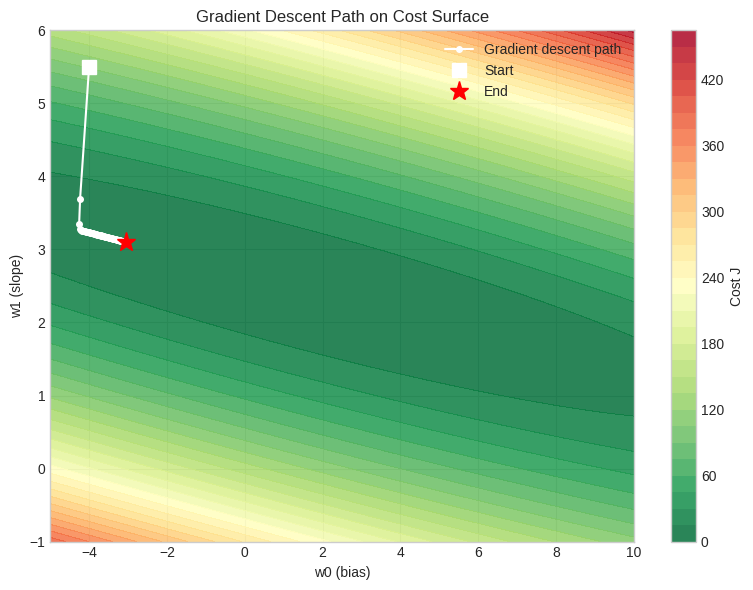

Final weights: w0 = -3.047, w1 = 3.099
True weights:  w0 = 1.000, w1 = 2.500


In [13]:
# ── Plot 2: Gradient Descent path on the cost surface ───────────────────────
# Watch how gradient descent walks from a bad initial guess toward the minimum.

def compute_cost(w0, w1, x, y):
    m = len(y)
    y_pred = w0 + w1 * x
    return np.sum((y_pred - y)**2) / (2 * m)

def gradient_step(w0, w1, x, y, lr):
    m = len(y)
    y_pred = w0 + w1 * x
    error  = y_pred - y
    dw0 = np.sum(error) / m
    dw1 = np.sum(error * x) / m
    return w0 - lr * dw0, w1 - lr * dw1

# Run gradient descent and record path
w0, w1 = -4.0, 5.5   # bad initial guess
lr = 0.02
path = [(w0, w1)]

for _ in range(60):
    w0, w1 = gradient_step(w0, w1, x_data, y_data, lr)
    path.append((w0, w1))

path = np.array(path)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(W0, W1, J_grid, levels=30, cmap='RdYlGn_r', alpha=0.85)
plt.colorbar(cp, ax=ax, label='Cost J')

ax.plot(path[:, 0], path[:, 1], 'w-o', markersize=4, linewidth=1.5,
        label='Gradient descent path', zorder=5)
ax.plot(path[0, 0], path[0, 1], 'ws', markersize=10, label='Start', zorder=6)
ax.plot(path[-1, 0], path[-1, 1], 'r*', markersize=14, label='End', zorder=6)

ax.set_xlabel('w0 (bias)')
ax.set_ylabel('w1 (slope)')
ax.set_title('Gradient Descent Path on Cost Surface')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final weights: w0 = {path[-1,0]:.3f}, w1 = {path[-1,1]:.3f}")
print(f"True weights:  w0 = 1.000, w1 = 2.500")


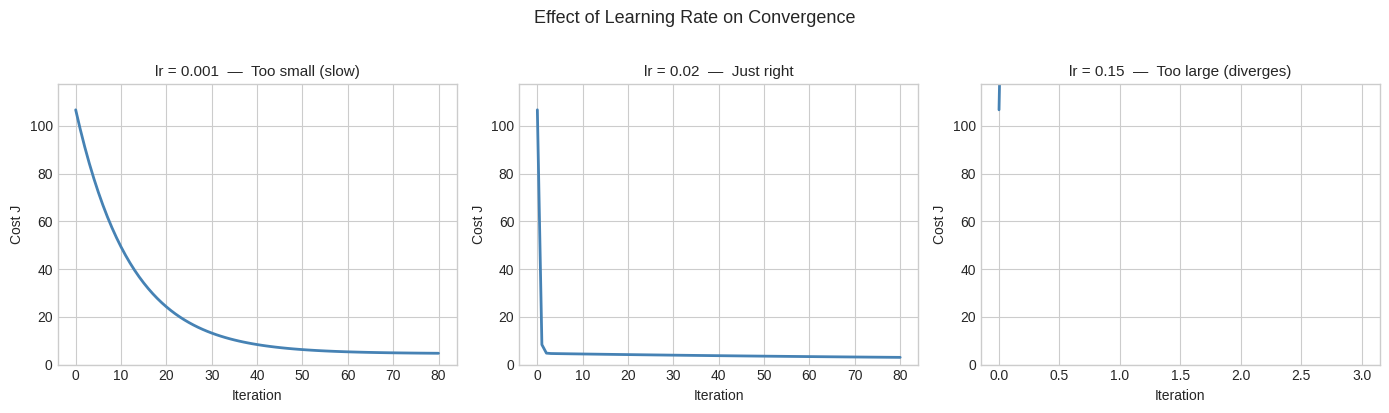

In [14]:
# ── Plot 3: Effect of learning rate ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

learning_rates = [0.001, 0.02, 0.15]
titles = ['Too small (slow)', 'Just right', 'Too large (diverges)']

for ax, lr_val, title in zip(axes, learning_rates, titles):
    w0_run, w1_run = -4.0, 5.5
    costs = [compute_cost(w0_run, w1_run, x_data, y_data)]

    for _ in range(80):
        w0_run, w1_run = gradient_step(w0_run, w1_run, x_data, y_data, lr_val)
        c = compute_cost(w0_run, w1_run, x_data, y_data)
        costs.append(c)
        if c > 1e6:   # diverged
            break

    costs = np.array(costs)
    ax.plot(costs, color='steelblue', linewidth=2)
    ax.set_title(f'lr = {lr_val}  —  {title}', fontsize=11)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost J')
    ax.set_ylim(0, min(costs[0] * 1.1, 200))

plt.suptitle('Effect of Learning Rate on Convergence', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Code from Scratch

Implementing linear regression using only NumPy — this is the best way to make sure you understand every step.

In [15]:
class LinearRegressionScratch:
    """
    Linear Regression using Gradient Descent.
    Implements the update rule:
        w := w - (alpha / m) * X^T * (Xw - y)
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.weights      = None   # includes bias as w[0]
        self.cost_history = []

    def _add_bias(self, X):
        """Prepend a column of 1s to X for the bias term."""
        m = X.shape[0]
        return np.hstack([np.ones((m, 1)), X])

    def fit(self, X, y):
        X_b = self._add_bias(X)          # shape (m, n+1)
        m, n = X_b.shape
        self.weights = np.zeros(n)        # initialize weights to 0

        for _ in range(self.n_iterations):
            y_pred  = X_b @ self.weights                     # (m,)
            error   = y_pred - y                             # (m,)
            grad    = (X_b.T @ error) / m                   # (n+1,)
            self.weights -= self.lr * grad

            cost = np.sum(error**2) / (2 * m)
            self.cost_history.append(cost)

        return self

    def predict(self, X):
        X_b = self._add_bias(X)
        return X_b @ self.weights

    def score(self, X, y):
        """R² score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - ss_res / ss_tot


In [16]:
# ── Generate dataset ────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
m = 200

# True relationship: y = 3 + 1.5*x1 + 2.0*x2 + noise
X = rng.uniform(0, 10, (m, 2))
y = 3.0 + 1.5 * X[:, 0] + 2.0 * X[:, 1] + rng.normal(0, 1.5, m)

# Train/test split (manual)
split = int(0.8 * m)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Feature scaling — critical for gradient descent
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
X_train_s = (X_train - mean) / std
X_test_s  = (X_test  - mean) / std   # use TRAIN mean/std on test


Learned weights: w0=19.992, w1=4.393, w2=5.464
Train R²: 0.9605
Test  R²: 0.9533


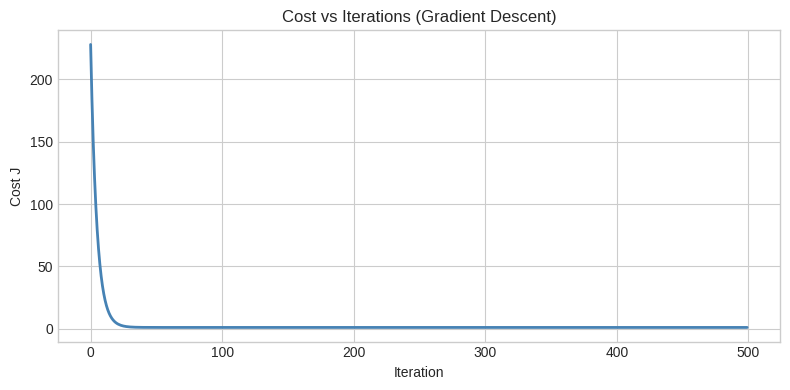

In [17]:
# ── Train and evaluate ──────────────────────────────────────────────────────
model = LinearRegressionScratch(learning_rate=0.1, n_iterations=500)
model.fit(X_train_s, y_train)

print(f"Learned weights: w0={model.weights[0]:.3f}, w1={model.weights[1]:.3f}, w2={model.weights[2]:.3f}")
print(f"Train R²: {model.score(X_train_s, y_train):.4f}")
print(f"Test  R²: {model.score(X_test_s,  y_test):.4f}")

# Plot cost convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.cost_history, color='steelblue', linewidth=2)
ax.set_title("Cost vs Iterations (Gradient Descent)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J")
plt.tight_layout()
plt.show()


In [18]:
# ── Normal Equation implementation ──────────────────────────────────────────
class LinearRegressionNormalEq:
    """
    Linear Regression using the Normal Equation:
        w* = (X^T X)^{-1} X^T y
    Exact solution — no iterations, no learning rate.
    """

    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        m = X.shape[0]
        X_b = np.hstack([np.ones((m, 1)), X])          # add bias column
        # (X^T X)^{-1} X^T y
        self.weights = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self

    def predict(self, X):
        m = X.shape[0]
        X_b = np.hstack([np.ones((m, 1)), X])
        return X_b @ self.weights

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - ss_res / ss_tot

# Normal equation does not need scaled features
ne_model = LinearRegressionNormalEq()
ne_model.fit(X_train, y_train)

print("Normal Equation weights:")
print(f"  w0={ne_model.weights[0]:.3f}  (true: 3.0)")
print(f"  w1={ne_model.weights[1]:.3f}  (true: 1.5)")
print(f"  w2={ne_model.weights[2]:.3f}  (true: 2.0)")
print(f"\nTest R²: {ne_model.score(X_test, y_test):.4f}")


Normal Equation weights:
  w0=3.174  (true: 3.0)
  w1=1.541  (true: 1.5)
  w2=1.912  (true: 2.0)

Test R²: 0.9533


## 5. Sklearn Implementation

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline — always use this to prevent data leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Sklearn LinearRegression:")
print(f"  Intercept:   {pipe.named_steps['model'].intercept_:.3f}  (true: 3.0)")
print(f"  Coefficients: {pipe.named_steps['model'].coef_}  (true: [1.5, 2.0])")
print(f"  Test RMSE:    {rmse:.4f}")
print(f"  Test R²:      {r2_score(y_test, y_pred):.4f}")


Sklearn LinearRegression:
  Intercept:   19.992  (true: 3.0)
  Coefficients: [4.39287409 5.4636918 ]  (true: [1.5, 2.0])
  Test RMSE:    1.3858
  Test R²:      0.9533


In [20]:
# Cross-validation — more reliable performance estimate
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
print(f"5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds: {cv_scores.round(4)}")


5-Fold CV R²: 0.9560 ± 0.0071
Individual folds: [0.9653 0.9463 0.9629 0.9524 0.9533]


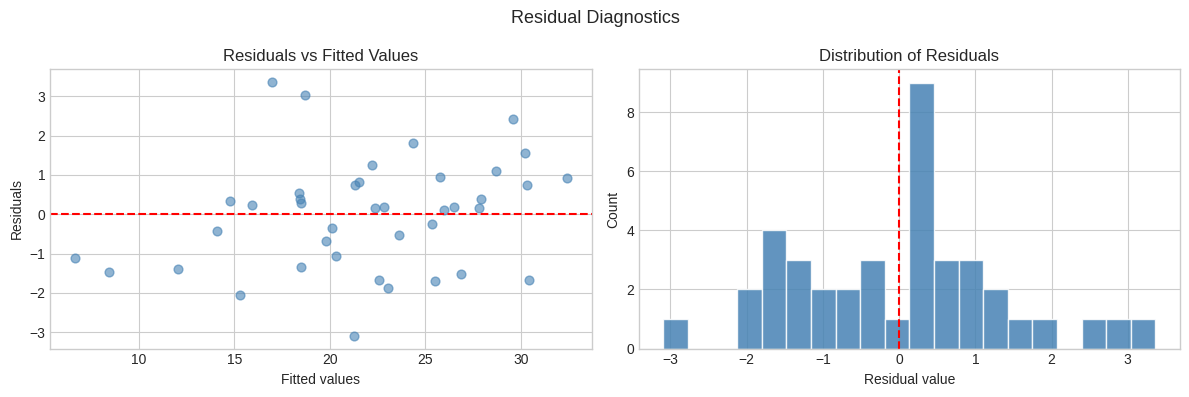

In [21]:
# Residual plot — a must-have diagnostic
y_pred_all = pipe.predict(X_test)
residuals  = y_test - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
axes[0].scatter(y_pred_all, residuals, alpha=0.6, color='steelblue', s=40)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

# Residuals distribution — should be roughly normal
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual value")
axes[1].set_ylabel("Count")

plt.suptitle("Residual Diagnostics", fontsize=13)
plt.tight_layout()
plt.show()

# Good signs: residuals centered at 0, no obvious pattern, roughly normal distribution


## 6. Assumptions of Linear Regression

Linear regression has 5 key assumptions. Violating them does not break the model but it makes predictions unreliable and coefficients untrustworthy.

| Assumption | What it means | How to check |
|---|---|---|
| **Linearity** | Relationship between X and y is linear | Scatter plots, residuals vs fitted |
| **Independence** | Observations are independent of each other | Domain knowledge, Durbin-Watson test |
| **Homoscedasticity** | Residuals have constant variance | Residuals vs fitted — should be a horizontal band |
| **Normality** | Residuals are normally distributed | Q-Q plot, histogram of residuals |
| **No multicollinearity** | Features are not highly correlated with each other | Correlation matrix, VIF scores |


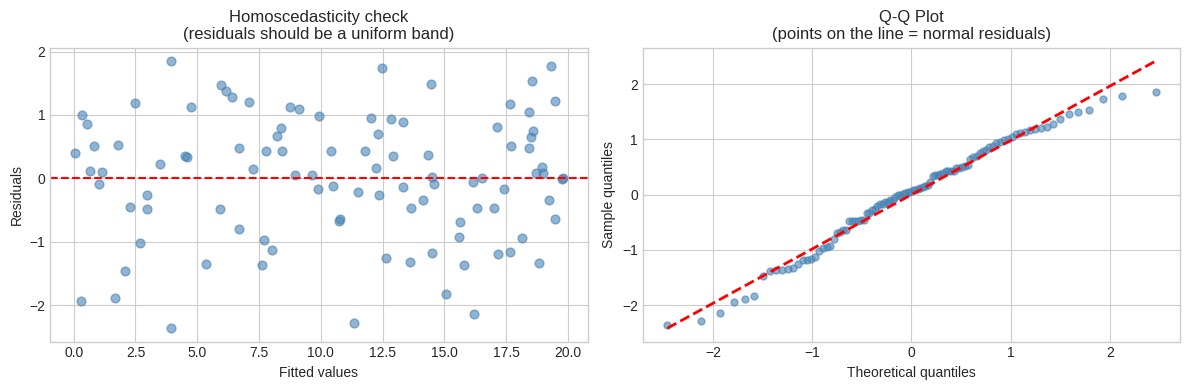

In [22]:
# Check homoscedasticity and normality together
from scipy import stats

rng2 = np.random.default_rng(0)
X_check = rng2.uniform(0, 10, (100, 1))
y_check  = 2 * X_check[:, 0] + rng2.normal(0, 1, 100)

pipe2 = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
pipe2.fit(X_check, y_check)
residuals_check = y_check - pipe2.predict(X_check)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
axes[0].scatter(pipe2.predict(X_check), residuals_check, alpha=0.6, color='steelblue', s=40)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title("Homoscedasticity check\n(residuals should be a uniform band)")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

# Q-Q plot for normality
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_check, dist="norm")
axes[1].plot(osm, osr, 'o', color='steelblue', alpha=0.6, markersize=5)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=2)
axes[1].set_title("Q-Q Plot\n(points on the line = normal residuals)")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Sample quantiles")

plt.tight_layout()
plt.show()


## 7. Regularization — Ridge and Lasso

When a model overfits, regularization adds a penalty to the cost function for large weights.

### Ridge Regression (L2)

$$J(\mathbf{w}) = \frac{1}{2m} \|X\mathbf{w} - \mathbf{y}\|^2 + \lambda \|\mathbf{w}\|^2$$

The $\lambda \|\mathbf{w}\|^2$ term penalizes large weights — forces the model to keep weights small. Closed-form solution becomes:

$$\mathbf{w}^* = (X^T X + \lambda I)^{-1} X^T \mathbf{y}$$

The $\lambda I$ term also makes the matrix invertible even when $X^T X$ is singular.

### Lasso Regression (L1)

$$J(\mathbf{w}) = \frac{1}{2m} \|X\mathbf{w} - \mathbf{y}\|^2 + \lambda \|\mathbf{w}\|_1$$

The L1 penalty drives some weights to **exactly zero** — effectively performing feature selection.

**Key difference:**
- Ridge shrinks all weights toward zero but keeps them all
- Lasso shrinks some weights to exactly zero — sparse models, built-in feature selection


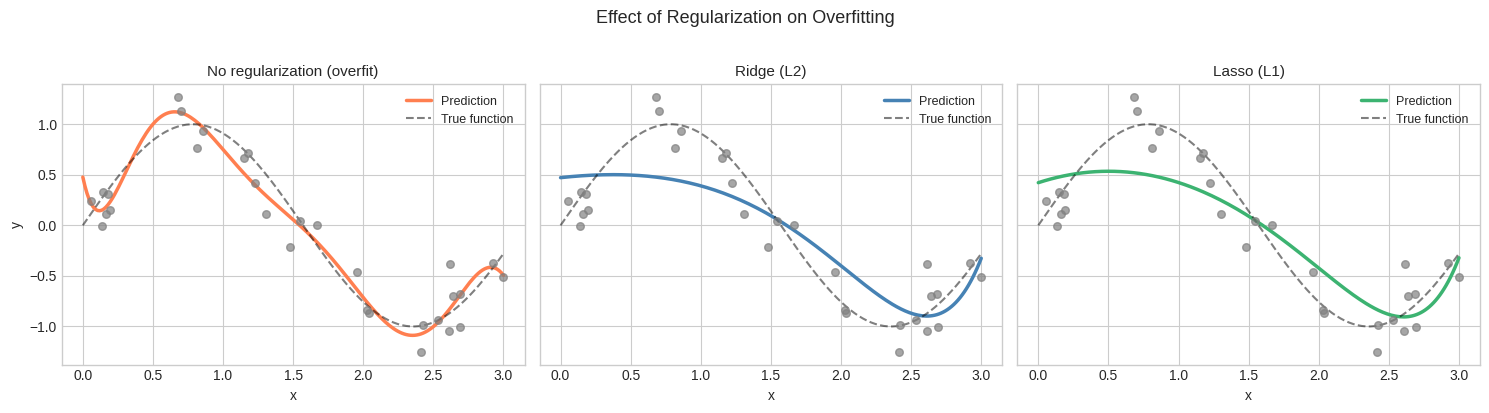

Non-zero Lasso coefficients: 3 out of 9


In [23]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# Create a dataset that overfits a plain linear model
rng3 = np.random.default_rng(5)
X_reg = rng3.uniform(0, 3, (30, 1))
y_reg = np.sin(X_reg[:, 0] * 2) + rng3.normal(0, 0.2, 30)
X_reg_test = np.linspace(0, 3, 200).reshape(-1, 1)

# Use polynomial features to expose overfitting
poly = PolynomialFeatures(degree=9, include_bias=False)
X_poly       = poly.fit_transform(X_reg)
X_poly_test  = poly.transform(X_reg_test)

scaler_r = StandardScaler()
X_poly_s      = scaler_r.fit_transform(X_poly)
X_poly_test_s = scaler_r.transform(X_poly_test)

plain  = LinearRegression().fit(X_poly_s, y_reg)
ridge  = Ridge(alpha=1.0).fit(X_poly_s, y_reg)
lasso  = Lasso(alpha=0.01, max_iter=10000).fit(X_poly_s, y_reg)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
x_plot = X_reg_test[:, 0]
y_true_plot = np.sin(x_plot * 2)

for ax, model, title, color in zip(
        axes,
        [plain, ridge, lasso],
        ['No regularization (overfit)', 'Ridge (L2)', 'Lasso (L1)'],
        ['coral', 'steelblue', 'mediumseagreen']):
    ax.scatter(X_reg[:, 0], y_reg, color='gray', s=30, alpha=0.7, zorder=3)
    ax.plot(x_plot, model.predict(X_poly_test_s), color=color, linewidth=2.5, label='Prediction')
    ax.plot(x_plot, y_true_plot, 'k--', linewidth=1.5, alpha=0.5, label='True function')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.legend(fontsize=9)

axes[0].set_ylabel("y")
plt.suptitle("Effect of Regularization on Overfitting", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Non-zero Lasso coefficients:", np.sum(lasso.coef_ != 0), "out of", len(lasso.coef_))


## 8. Common Mistakes

/tmp/ipykernel_4584/214424034.py:30: RuntimeWarning: overflow encountered in square
  cost = np.sum(error**2) / (2 * m)
/tmp/ipykernel_4584/214424034.py:27: RuntimeWarning: overflow encountered in matmul
  grad    = (X_b.T @ error) / m                   # (n+1,)
/tmp/ipykernel_4584/214424034.py:27: RuntimeWarning: invalid value encountered in matmul
  grad    = (X_b.T @ error) / m                   # (n+1,)
/tmp/ipykernel_4584/214424034.py:28: RuntimeWarning: invalid value encountered in subtract
  self.weights -= self.lr * grad


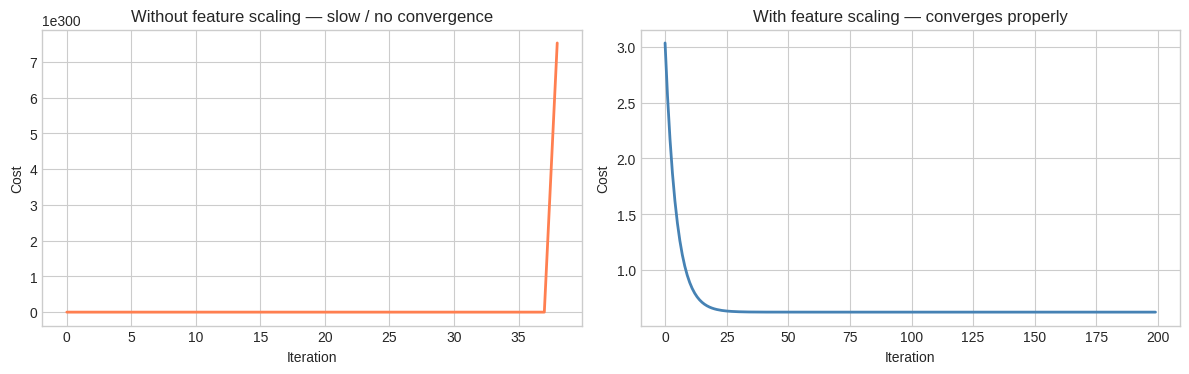

In [24]:
# MISTAKE 1: Not scaling features before gradient descent
# Unscaled features cause wildly different gradient magnitudes, slow convergence

rng4 = np.random.default_rng(0)
X_bad = np.column_stack([
    rng4.normal(0, 1, 100),          # feature 1: scale ~1
    rng4.normal(0, 1000, 100)        # feature 2: scale ~1000
])
y_bad = 2 * X_bad[:, 0] + 0.001 * X_bad[:, 1] + rng4.normal(0, 1, 100)

# Without scaling — cost barely moves
model_no_scale = LinearRegressionScratch(learning_rate=0.01, n_iterations=200)
model_no_scale.fit(X_bad, y_bad)

# With scaling — converges properly
X_bad_s = (X_bad - X_bad.mean(axis=0)) / X_bad.std(axis=0)
model_scaled = LinearRegressionScratch(learning_rate=0.1, n_iterations=200)
model_scaled.fit(X_bad_s, y_bad)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(model_no_scale.cost_history, color='coral', linewidth=2)
axes[0].set_title("Without feature scaling — slow / no convergence")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost")

axes[1].plot(model_scaled.cost_history, color='steelblue', linewidth=2)
axes[1].set_title("With feature scaling — converges properly")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost")

plt.tight_layout()
plt.show()


In [25]:
# MISTAKE 2: Fitting scaler on full data (data leakage)

# WRONG — scaler sees test data during fit
scaler_wrong = StandardScaler()
X_all_scaled = scaler_wrong.fit_transform(X)     # leaks test distribution into train

# CORRECT — fit only on train, transform both
scaler_right = StandardScaler()
X_train_right = scaler_right.fit_transform(X_train)  # fit on train only
X_test_right  = scaler_right.transform(X_test)       # apply same transform to test

# Easiest correct way: use Pipeline — it handles this automatically
pipe_correct = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
# pipe.fit(X_train, y_train) only fits scaler on X_train
# pipe.predict(X_test) applies the same transform to X_test
print("Always use Pipeline to prevent data leakage.")


Always use Pipeline to prevent data leakage.


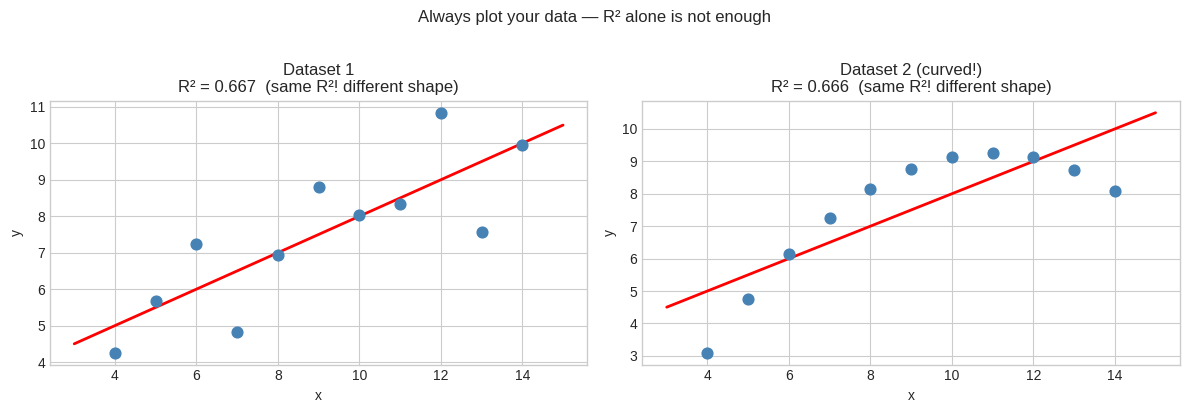

In [26]:
# MISTAKE 3: Using R² alone — ignoring residual patterns
# A high R² does not mean the model is correct.
# Anscombe's Quartet: 4 datasets with identical statistics but very different structure.

x1 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y1 = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])

x2 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, x, y, title in zip(axes, [x1, x2], [y1, y2], ['Dataset 1', 'Dataset 2 (curved!)']):
    m_tmp = LinearRegression().fit(x.reshape(-1,1), y)
    x_line_tmp = np.linspace(3, 15, 100)
    ax.scatter(x, y, color='steelblue', s=60, zorder=3)
    ax.plot(x_line_tmp, m_tmp.predict(x_line_tmp.reshape(-1,1)), 'r-', linewidth=2)
    r2 = r2_score(y, m_tmp.predict(x.reshape(-1,1)))
    ax.set_title(f'{title}\nR² = {r2:.3f}  (same R²! different shape)')
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Always plot your data — R² alone is not enough", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 9. Exercises

**Exercise 1:** Using the scratch implementation, manually verify the Normal Equation gives the same weights as gradient descent (after convergence) on a simple 1-feature dataset.

In [27]:
# Your code here


In [28]:
# Solution
rng_ex = np.random.default_rng(1)
X_ex = rng_ex.uniform(0, 5, (50, 1))
y_ex = 4.0 + 2.5 * X_ex[:, 0] + rng_ex.normal(0, 0.5, 50)

# Gradient descent
X_ex_s = (X_ex - X_ex.mean()) / X_ex.std()
gd = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000).fit(X_ex_s, y_ex)

# Normal equation (unscaled)
ne = LinearRegressionNormalEq().fit(X_ex, y_ex)

print(f"GD weights (scaled):    w0={gd.weights[0]:.4f}, w1={gd.weights[1]:.4f}")
print(f"Normal Eq weights:      w0={ne.weights[0]:.4f}, w1={ne.weights[1]:.4f}")
print(f"True weights:           w0=4.0, w1=2.5")
print("\nBoth methods converge to the same solution (different scale due to feature scaling).")


GD weights (scaled):    w0=10.4464, w1=3.4777
Normal Eq weights:      w0=3.9269, w1=2.5089
True weights:           w0=4.0, w1=2.5

Both methods converge to the same solution (different scale due to feature scaling).


**Exercise 2:** Add L2 regularization (Ridge) to the `LinearRegressionScratch` class. The gradient of the regularized cost is:
$$\frac{\partial J_{ridge}}{\partial \mathbf{w}} = \frac{1}{m} X^T(X\mathbf{w} - \mathbf{y}) + \frac{\lambda}{m} \mathbf{w}$$
Note: do **not** regularize the bias term $w_0$.


In [29]:
# Your code here


In [30]:
# Solution
class RidgeRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000, lambda_=1.0):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.lambda_      = lambda_
        self.weights      = None
        self.cost_history = []

    def fit(self, X, y):
        m = X.shape[0]
        X_b = np.hstack([np.ones((m, 1)), X])
        self.weights = np.zeros(X_b.shape[1])

        for _ in range(self.n_iterations):
            error = X_b @ self.weights - y
            grad  = (X_b.T @ error) / m

            # Add L2 penalty — but NOT to the bias (index 0)
            reg_term         = (self.lambda_ / m) * self.weights.copy()
            reg_term[0]      = 0   # no penalty on bias
            grad            += reg_term

            self.weights -= self.lr * grad
            cost = np.sum(error**2) / (2*m) + (self.lambda_ / (2*m)) * np.sum(self.weights[1:]**2)
            self.cost_history.append(cost)

        return self

    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.weights

rng_ex2 = np.random.default_rng(7)
X_ex2 = rng_ex2.uniform(0, 5, (50, 1))
y_ex2 = 3 + 2 * X_ex2[:, 0] + rng_ex2.normal(0, 1.5, 50)
X_ex2_s = (X_ex2 - X_ex2.mean()) / X_ex2.std()

for lam in [0.0, 1.0, 10.0]:
    ridge_scratch = RidgeRegressionScratch(learning_rate=0.1, n_iterations=500, lambda_=lam)
    ridge_scratch.fit(X_ex2_s, y_ex2)
    print(f"lambda={lam:4.1f}  →  w0={ridge_scratch.weights[0]:.3f}, w1={ridge_scratch.weights[1]:.3f}")


lambda= 0.0  →  w0=7.988, w1=2.722
lambda= 1.0  →  w0=7.988, w1=2.669
lambda=10.0  →  w0=7.988, w1=2.269


**Exercise 3:** On the Ames Housing dataset (or any regression dataset), train a linear regression model and check all 5 assumptions. Write a function that produces the full diagnostic plot (residuals vs fitted, Q-Q plot, scale-location, residuals vs leverage) in a 2x2 grid.

In [31]:
# Your code here


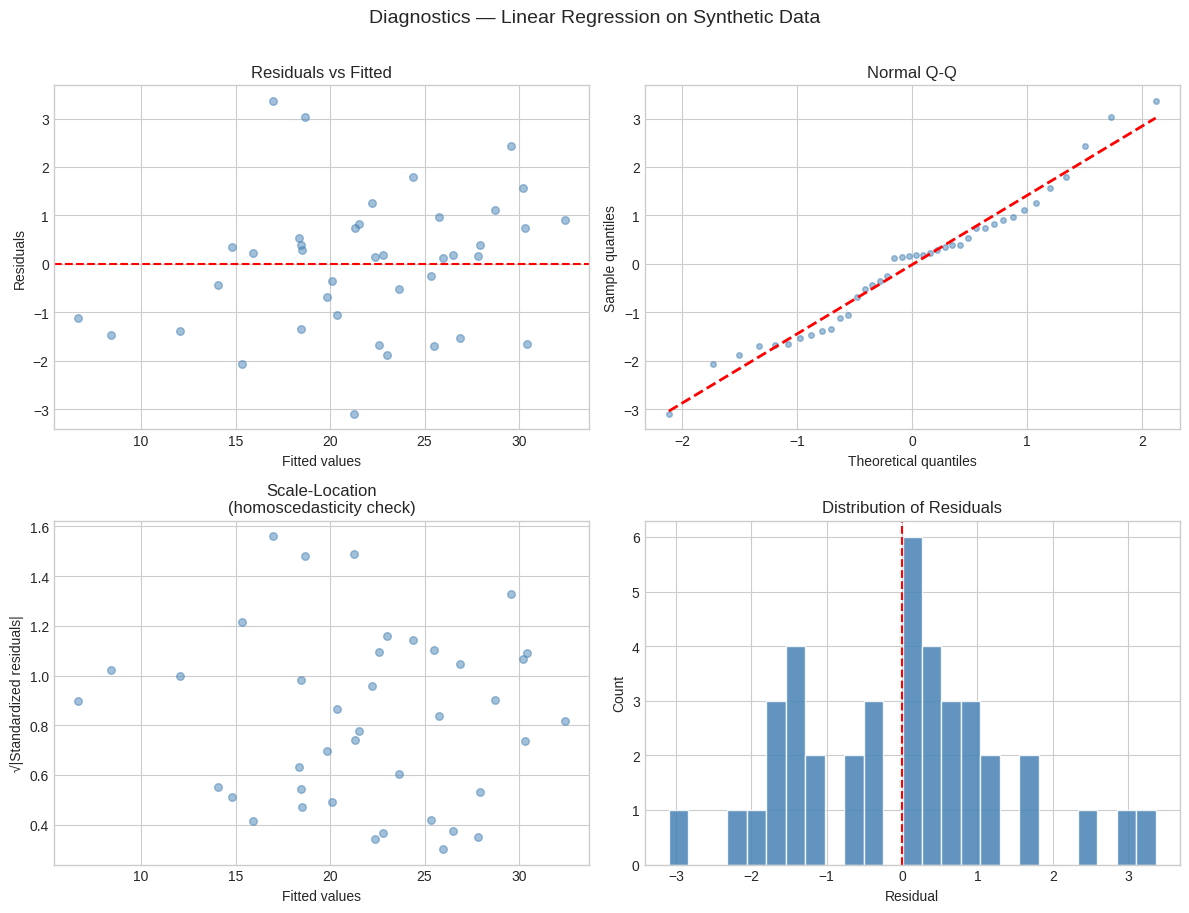

In [32]:
# Solution
from scipy import stats

def regression_diagnostics(model, X, y, title="Regression Diagnostics"):
    y_pred    = model.predict(X)
    residuals = y - y_pred
    std_res   = (residuals - residuals.mean()) / residuals.std()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # 1. Residuals vs Fitted
    axes[0,0].scatter(y_pred, residuals, alpha=0.5, color='steelblue', s=30)
    axes[0,0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0,0].set_title("Residuals vs Fitted")
    axes[0,0].set_xlabel("Fitted values")
    axes[0,0].set_ylabel("Residuals")

    # 2. Q-Q plot
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
    axes[0,1].plot(osm, osr, 'o', color='steelblue', alpha=0.5, markersize=4)
    axes[0,1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=2)
    axes[0,1].set_title("Normal Q-Q")
    axes[0,1].set_xlabel("Theoretical quantiles")
    axes[0,1].set_ylabel("Sample quantiles")

    # 3. Scale-Location (sqrt(|std residuals|) vs fitted)
    axes[1,0].scatter(y_pred, np.sqrt(np.abs(std_res)), alpha=0.5, color='steelblue', s=30)
    axes[1,0].set_title("Scale-Location\n(homoscedasticity check)")
    axes[1,0].set_xlabel("Fitted values")
    axes[1,0].set_ylabel("√|Standardized residuals|")

    # 4. Histogram of residuals
    axes[1,1].hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[1,1].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1,1].set_title("Distribution of Residuals")
    axes[1,1].set_xlabel("Residual")
    axes[1,1].set_ylabel("Count")

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Test it
pipe_diag = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
pipe_diag.fit(X_train, y_train)
regression_diagnostics(pipe_diag, X_test, y_test, title="Diagnostics — Linear Regression on Synthetic Data")


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
